In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Numerical Stability and Initialization


Every model so far has required us to initialize its parameters
from some chosen distribution, and we have taken those choices for granted.
They are not innocuous.
The initialization scheme interacts with the choice of activation function
to determine whether gradients flow at a usable scale,
or instead *vanish* (so learning stalls) or *explode* (so it diverges),
and hence how fast, or whether, optimization converges at all.
This section makes the failure modes concrete
and develops the variance-preserving heuristics
(Xavier and He initialization) that fix them.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import torch

## Vanishing and Exploding Gradients

Consider a deep network with $L$ layers,
input $\mathbf{x}$ and output $\mathbf{o}$.
With each layer $l$ defined by a transformation $f_l$
parametrized by weights $\mathbf{W}^{(l)}$,
whose hidden layer output is $\mathbf{h}^{(l)}$ (let $\mathbf{h}^{(0)} = \mathbf{x}$),
our network can be expressed as:

$$\mathbf{h}^{(l)} = f_l (\mathbf{h}^{(l-1)}) \textrm{ and thus } \mathbf{o} = f_L \circ \cdots \circ f_1(\mathbf{x}).$$

If all the hidden layer output and the input are vectors,
we can write the gradient of $\mathbf{o}$ with respect to
any set of parameters $\mathbf{W}^{(l)}$ as follows:

$$\partial_{\mathbf{W}^{(l)}} \mathbf{o} = \underbrace{\partial_{\mathbf{h}^{(L-1)}} \mathbf{h}^{(L)}}_{ \mathbf{M}^{(L)} \stackrel{\textrm{def}}{=}} \cdots \underbrace{\partial_{\mathbf{h}^{(l)}} \mathbf{h}^{(l+1)}}_{ \mathbf{M}^{(l+1)} \stackrel{\textrm{def}}{=}} \underbrace{\partial_{\mathbf{W}^{(l)}} \mathbf{h}^{(l)}}_{ \mathbf{v}^{(l)} \stackrel{\textrm{def}}{=}}.$$

In other words, this gradient is
the product of $L-l$ matrices
$\mathbf{M}^{(L)} \cdots \mathbf{M}^{(l+1)}$
and the gradient operator $\mathbf{v}^{(l)}$.
Thus we are susceptible to the same
problems of numerical underflow that often crop up
when multiplying together too many probabilities.
When dealing with probabilities, a common trick is to
switch into log-space, i.e., shifting
pressure from the mantissa to the exponent
of the numerical representation.
Unfortunately, our problem above is more serious:
each Jacobian $\mathbf{M}^{(l)}$ can stretch or shrink the vectors it acts on
by widely varying factors (its *singular values*: for the rectangular
Jacobians that arise when layer widths differ, these are the right notion of
"how much the matrix scales things").
A per-layer factor of $\rho$ compounds to $\rho^{\,L-l}$ across the product,
so factors even modestly different from $1$
make the overall gradient *very large* or *very small* geometrically fast;
the growth rate of such a product's singular values is developed
in that section.

The risks posed by unstable gradients
go beyond numerical representation.
Gradients of unpredictable magnitude
also threaten the stability of our optimization algorithms.
We may be facing parameter updates that are either
(i) excessively large, destroying our model
(the *exploding gradient* problem);
or (ii) excessively small
(the *vanishing gradient* problem),
rendering learning impossible as parameters
hardly move on each update.


### Vanishing Gradients

One frequent culprit causing the vanishing gradient problem
is the choice of the activation function $\sigma$
that is appended following each layer's linear operations.
Historically, the sigmoid function
$1/(1 + \exp(-x))$ (introduced in that section)
was popular because it resembles a thresholding function.
Since early artificial neural networks were inspired
by biological neural networks,
the idea of neurons that fire either *fully* or *not at all*
(like biological neurons) seemed appealing.
Let's take a closer look at the sigmoid
to see why it can cause vanishing gradients.

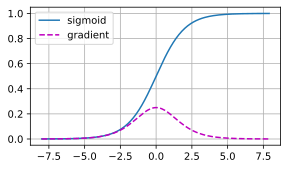

In [2]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.backward(torch.ones_like(x))

d2l.plot(x.detach().numpy(), [y.detach().numpy(), x.grad.numpy()],
         legend=['sigmoid', 'gradient'], figsize=(4.5, 2.5))

As you can see, the sigmoid's gradient vanishes
both when its inputs are large and when they are small.
Moreover, the sigmoid's derivative *never exceeds* $0.25$
(its peak, attained at zero),
so even in the Goldilocks zone,
where the inputs to many of the sigmoids are close to zero,
each layer attenuates the backward signal by at least a factor of four:
after only ten sigmoid layers the gradient has shrunk
by $0.25^{10} \approx 10^{-6}$.
Away from that zone the situation is far worse,
and the gradients of the overall product vanish outright.
When our network has many layers,
unless we are careful, the gradient
will likely be cut off at some layer.
Indeed, this problem used to plague deep network training [@bengio1994learning].
Consequently, ReLUs, which are more stable
(but less neurally plausible),
have emerged as the default choice for practitioners.


### Exploding Gradients

The opposite problem, when gradients explode,
can be similarly vexing.
To illustrate this a bit better,
we draw 100 Gaussian random matrices
and multiply them with some initial matrix.
For the scale that we picked
(the choice of the variance $\sigma^2=1$),
the matrix product explodes.
When this happens because of the initialization
of a deep network, we have no chance of getting
a gradient descent optimizer to converge.

In [3]:
M = torch.normal(0, 1, size=(4, 4))
print('a single matrix \n',M)
for i in range(100):
    M = M @ torch.normal(0, 1, size=(4, 4))
print('after multiplying 100 matrices\n', M)

a single matrix 
 tensor([[-0.9753, -2.4309, -0.6217, -0.9488],
        [ 0.5474, -0.3909,  1.7120,  0.4327],
        [ 1.6211, -0.4342,  1.1437, -0.6168],
        [-0.5642, -0.6920,  0.6003,  0.9131]])
after multiplying 100 matrices
 tensor([[ 1.1962e+23,  1.0111e+23,  1.3713e+23, -2.7019e+23],
        [ 7.4143e+21,  6.2674e+21,  8.4994e+21, -1.6747e+22],
        [-1.2204e+23, -1.0316e+23, -1.3990e+23,  2.7565e+23],
        [ 1.0273e+23,  8.6837e+22,  1.1777e+23, -2.3204e+23]])


### Breaking the Symmetry

Another problem in neural network design
is the symmetry inherent in their parametrization.
Assume that we have a simple MLP
with one hidden layer and two units.
In this case, we could permute the weights $\mathbf{W}^{(1)}$
of the first layer and likewise permute
the weights of the output layer
to obtain the same function.
There is nothing special differentiating
the first and second hidden units.
In other words, we have permutation symmetry
among the hidden units of each layer.

This is more than just a theoretical nuisance.
Consider the aforementioned one-hidden-layer MLP
with two hidden units.
For illustration,
suppose that the output layer transforms the two hidden units into only one output unit.
Imagine what would happen if we initialized
all the parameters of the hidden layer
as $\mathbf{W}^{(1)} = c$ for some constant $c$.
In this case, during forward propagation
either hidden unit takes the same inputs and parameters
producing the same activation
which is fed to the output unit.
During backpropagation,
differentiating the output unit with respect to parameters $\mathbf{W}^{(1)}$ gives a gradient all of whose elements take the same value.
Thus, after gradient-based iteration (e.g., minibatch stochastic gradient descent),
all the elements of $\mathbf{W}^{(1)}$ still take the same value.
Such iterations would
never *break the symmetry* on their own
and we might never be able to realize
the network's expressive power.
The hidden layer would behave
as if it had only a single unit.
Note that while minibatch stochastic gradient descent would not break this symmetry,
dropout regularization (that section) would!


## Parameter Initialization

One way of addressing (or at least mitigating) the
issues raised above is through careful initialization.
As we will see later,
additional care during optimization
and suitable regularization can further enhance stability.


### Default Initialization

In the previous sections, e.g., in that section,
we initialized weights by drawing them from a normal distribution
with a small, fixed standard deviation.
If we do not specify an initialization method at all,
the library falls back to its own default scheme. These defaults differ across
libraries and layer types: some scale with fan-in, while others use a fixed
range. They are conveniences rather than a portable mathematical guarantee.
For an experiment whose initialization matters, choose a named initializer
explicitly and record its parameters.
Defaults often work well for moderately sized networks.
They become unreliable, however, as depth grows.
The variance analysis that follows explains both *why* they work
and *where* they break, and what to reach for instead.


### Xavier Initialization

Let's look at the scale distribution of
an output $o_{i}$ for some fully connected layer
*without nonlinearities*.
With $n_\textrm{in}$ inputs $x_j$
and their associated weights $w_{ij}$ for this layer,
an output is given by

$$o_{i} = \sum_{j=1}^{n_\textrm{in}} w_{ij} x_j.$$

The weights $w_{ij}$ are all drawn
independently from the same distribution.
Furthermore, let's assume that this distribution
has zero mean and variance $\sigma^2$.
Note that this does not mean that the distribution has to be Gaussian,
just that the mean and variance need to exist.
For now, let's assume that the inputs to the layer $x_j$
also have zero mean and variance $\gamma^2$
and that they are independent of $w_{ij}$ and independent of each other.
In this case, we can compute the mean of $o_i$:

$$
\begin{aligned}
    E[o_i] & = \sum_{j=1}^{n_\textrm{in}} E[w_{ij} x_j] \\&= \sum_{j=1}^{n_\textrm{in}} E[w_{ij}] E[x_j] \\&= 0, \end{aligned}$$

and the variance:

$$
\begin{aligned}
    \textrm{Var}[o_i] & = E[o_i^2] - (E[o_i])^2 \\
        & = \sum_{j=1}^{n_\textrm{in}} E[w^2_{ij} x^2_j] - 0 \\
        & = \sum_{j=1}^{n_\textrm{in}} E[w^2_{ij}] E[x^2_j] \\
        & = n_\textrm{in} \sigma^2 \gamma^2.
\end{aligned}
$$

Here we used $E[w_{ij}^2] = \textrm{Var}[w_{ij}] = \sigma^2$,
which holds because the weights have zero mean
($\textrm{Var}[w] = E[w^2] - E[w]^2 = E[w^2]$),
and likewise $E[x_j^2] = \gamma^2$.
In the second line, expanding the square of the sum also produces cross terms
$E[w_{ij} w_{ik} x_j x_k]$ for $j \neq k$;
these vanish because the weights are independent of each other
(and of the inputs) and have zero mean.

One way to keep the variance fixed
is to set $n_\textrm{in} \sigma^2 = 1$.
Now consider backpropagation.
A gradient signal flowing *back* through this layer
is multiplied by $\mathbf{W}^\top$,
so by the identical variance computation,
now summing over the $n_\textrm{out}$ outputs the layer feeds,
its variance is scaled by $n_\textrm{out} \sigma^2$.
Keeping the *backward* signal's variance fixed
therefore requires $n_\textrm{out} \sigma^2 = 1$,
where $n_\textrm{out}$ is the number of outputs of this layer.
This leaves us in a dilemma:
we cannot satisfy both conditions simultaneously unless $n_\textrm{in}=n_\textrm{out}$.
Instead, we simply try to satisfy:

$$
\begin{aligned}
\frac{1}{2} (n_\textrm{in} + n_\textrm{out}) \sigma^2 = 1 \textrm{ or equivalently }
\sigma = \sqrt{\frac{2}{n_\textrm{in} + n_\textrm{out}}}.
\end{aligned}
$$

This is the reasoning underlying the now-standard
and practically beneficial *Xavier initialization*,
named after the first author of its creators [@Glorot.Bengio.2010].
Typically, the Xavier initialization
samples weights from a Gaussian distribution
with zero mean and variance
$\sigma^2 = \frac{2}{n_\textrm{in} + n_\textrm{out}}$.
We can also adapt this to
choose the variance when sampling weights
from a uniform distribution.
Note that the uniform distribution $U(-a, a)$ has variance $\frac{a^2}{3}$.
Plugging $\frac{a^2}{3}$ into our condition on $\sigma^2$
prompts us to initialize according to

$$U\left(-\sqrt{\frac{6}{n_\textrm{in} + n_\textrm{out}}}, \sqrt{\frac{6}{n_\textrm{in} + n_\textrm{out}}}\right).$$

Though the assumption that there are no nonlinearities
in the above mathematical reasoning
can be easily violated in neural networks,
the Xavier initialization method
turns out to work well in practice.


### He Initialization

The Xavier analysis above assumed a layer *without nonlinearities*.
The argument breaks in a specific, fixable way once we insert a ReLU.
First, note what the variance computation above actually consumed. With
independent zero-mean weights, $E[o_i] = 0$, and
$E[o_i^2] = n_\textrm{in} \sigma^2 E[x_j^2]$ depends on the inputs only
through their *second moment* $E[x_j^2]$.
So the quantity we must track through the nonlinearity is the second moment.
Recall that $\textrm{ReLU}(z) = \max(0, z)$ zeroes every negative pre-activation
and passes every positive one through unchanged.
If the pre-activations are symmetric about zero, as they are when the weights
have a symmetric distribution independent of the inputs,
then $\textrm{ReLU}(z)^2$ equals $z^2$ on the positive half of the distribution
and equals $0$ on the negative half,
so the rectifier **halves the second moment**:
$E[\textrm{ReLU}(z)^2] = \tfrac{1}{2}E[z^2]$.
(Its effect on the *variance* is messier, because $\textrm{ReLU}(z)$
is no longer zero-mean, as the exercises explore.)

Let $q=E[h_j^2]$ be the second moment entering a linear layer. Its
preactivation has second moment $n_\textrm{in}\sigma^2q$, and the following
ReLU produces
$q' = \tfrac{1}{2}n_\textrm{in}\sigma^2q$ under the symmetry and independence
assumptions above. To keep this second moment fixed across layers
we must compensate by *doubling* the weight variance:

$$\sigma^2 = \frac{2}{n_\textrm{in}}.$$

This is *He* (or *Kaiming*) *initialization* [@He.Zhang.Ren.ea.2015],
and it is the standard choice for the ReLU-family activations
this chapter uses throughout.
Because Xavier and He differ only by this factor of two
and by which fan size they key on, they are easy to confuse;
the rule of thumb is **Xavier for $\tanh$ and sigmoid, He for ReLU**.
Most libraries ship both as named initializers,
and we return to invoking them through the parameter-initialization API
in that section.


### Watching the Variance Propagate

The 100-matrix product above showed the *explosion* half of the story. Now
that we have the fix in hand, one plot shows all three regimes at once:
push a unit-scale signal through $50$ ReLU layers of
width $100$ and track the second moment $E[(h^{(l)})^2]$ of the activations
(the quantity the He argument preserves) layer by layer, under three weight
scales: the naive $\mathcal{N}(0,1)$, Xavier, and He. To avoid floating-point
overflow along the way, we renormalize the activations after each layer and
accumulate the per-layer gains instead; because ReLU is positively
homogeneous ($\operatorname{ReLU}(a\mathbf{x}) = a\operatorname{ReLU}(\mathbf{x})$
for $a > 0$), this rescaling is exact, not an approximation.

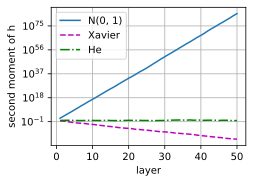

In [4]:
depth, width = 50, 100
scales = {'N(0, 1)': 1.0, 'Xavier': (2 / (width + width)) ** 0.5,
          'He': (2 / width) ** 0.5}
curves = []
for scale in scales.values():
    h, m, curve = torch.randn(1000, width), 1.0, []
    for _ in range(depth):
        h = torch.relu(h @ (scale * torch.randn(width, width)))
        gain = float((h ** 2).mean())  # this layer's factor on E[h^2]
        m *= gain
        curve.append(m)
        h = h / gain ** 0.5  # renormalize: exact, since ReLU is homogeneous
    curves.append(curve)
d2l.plot(list(range(1, depth + 1)), curves, 'layer', 'second moment of h',
         legend=list(scales), yscale='log')

The plot shows all three regimes at once. Under $\mathcal{N}(0,1)$ weights
each layer multiplies the signal's scale by roughly $n_\textrm{in}/2 = 50$, and
fifty layers compound that to an astronomical $\sim\!10^{80}$: the exploding
regime. Xavier, derived for *linear* layers, is off by exactly the rectifier's
factor of $\tfrac{1}{2}$ per layer, so the signal *vanishes* like $2^{-l}$,
reaching $\sim\!10^{-15}$ by the bottom of the stack. He initialization
compensates for the rectifier and holds the signal's scale essentially flat
across all fifty layers (the slight downward drift is a finite-width
fluctuation effect, not a bias in the rule). Only the He-initialized network
delivers usable forward signals. A related backward calculation gives the
same scaling under additional mean-field independence assumptions; it is an
initialization approximation, not an exact statement about gradients during
training. The exercises ask you to repeat the sweep with the
nonlinearity removed, where Xavier is the scheme that stays flat.

### Beyond

The reasoning above barely scratches the surface
of modern approaches to parameter initialization.
A deep learning framework often implements over a dozen different heuristics.
Moreover, parameter initialization continues to be
a hot area of fundamental research in deep learning.
Among these are heuristics specialized for
tied (shared) parameters, super-resolution,
sequence models, and other situations.
For instance,
@Xiao.Bahri.Sohl-Dickstein.ea.2018 demonstrated the possibility of training
10,000-layer neural networks without architectural tricks
by using a carefully-designed initialization method.

In very deep networks, normalization layers (that section)
and residual connections (that section)
largely remove this burden from initialization
by re-centering activations during training;
we cover them in later chapters.

If the topic interests you, read the papers that proposed and analyzed each
heuristic and the more recent work that builds on them.


## Summary

Vanishing and exploding gradients are common issues in deep networks. Great care in parameter initialization is required to ensure that gradients and parameters remain well controlled.
Initialization heuristics are needed to ensure that the initial gradients are neither too large nor too small.
Random initialization is key to ensuring that symmetry is broken before optimization.
Xavier initialization keeps the variance of activations and gradients roughly constant across layers by scaling weights according to the number of inputs and outputs.
For ReLU networks, He initialization scales the weight variance to $2/n_\textrm{in}$ to compensate for the rectifier halving the activations' second moment.
ReLU activation functions mitigate the vanishing gradient problem. This can accelerate convergence.

## Exercises

1. Can you design other cases where a neural network might exhibit symmetry that needs breaking, besides the permutation symmetry in an MLP's layers?
1. Can we initialize all weight parameters in linear regression or in softmax regression to the same value?
1. The Xavier derivation assumed a linear layer. Repeat it for a layer followed by a ReLU: show that, for zero-mean symmetric pre-activations $z$, $E[\textrm{ReLU}(z)^2] = \tfrac{1}{2}E[z^2]$, and conclude that preserving forward variance requires $\sigma^2 = 2/n_\textrm{in}$ (He initialization). Where does the factor of two come from intuitively? Why is the analogous statement for variances false? For $z \sim \mathcal{N}(0, \tau^2)$, compute $\textrm{Var}[\textrm{ReLU}(z)]$ explicitly and show that it equals $\left(\tfrac{1}{2} - \tfrac{1}{2\pi}\right)\tau^2$, not $\tfrac{1}{2}\tau^2$.
1. Rerun this section's depth-sweep experiment with the ReLU removed, i.e., for a purely *linear* stack of 50 layers of width 100 under the same three schemes. Which scheme keeps the signal's scale flat now, and why does the winner change relative to the ReLU sweep? What does this predict for activations that are approximately linear around zero, such as tanh?
1. Look up analytic bounds on the eigenvalues of the product of two matrices. What does this tell you about ensuring that gradients are well conditioned?
1. If we know that some terms diverge, can we fix this after the fact? Look at the paper on layerwise adaptive rate scaling  for inspiration [@You.Gitman.Ginsburg.2017].

[Discussions](https://d2l.discourse.group/t/104)